# Walmart Weekly Sales Forecasting
### Data Preprocessing

In [8]:
import pandas as pd

# Load the data
train = pd.read_csv("../data/train.csv")
stores = pd.read_csv("../data/stores.csv")
features = pd.read_csv("../data/features.csv")

# Create main table with left join (first with "stores", then with "features")
data = pd.merge(train, stores, on="Store", how="left")
data = pd.merge(data, features, on=["Store", "Date"], how="left")

# There are identical IsHoliday columns (IsHoldiay_x, IsHoliday_y), delete one of them and rename the other one
data = data.drop(columns="IsHoliday_y")
data = data.rename(columns={"IsHoliday_x": "IsHoliday"})

# There are blanks in the markdown columns. NaN values will be 0.
markdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
data[markdown_columns] = data[markdown_columns].fillna(0)

# --- NEW: HOCANIN İSTEDİĞİ FİLTRELEME VE BİRLEŞTİRME ---
# 1. Sadece İlk Mağazayı (Store 1) filtrele
data = data[data['Store'] == 1].reset_index(drop=True)

# 2. Departmanları Tarih bazında birleştir (Satışları topla, diğer özellikleri tekilleştir)
agg_rules = {
    'Weekly_Sales': 'sum',
    'IsHoliday': 'max',  # 1 veya 0 değerini korur
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean',
    'Size': 'max'        # Mağaza boyutu sabit kalır
}
data = data.groupby('Date').agg(agg_rules).reset_index()

print(data)

           Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price         CPI  \
0    2010-02-05    1643690.90      False        42.31       2.572  211.096358   
1    2010-02-12    1641957.44       True        38.51       2.548  211.242170   
2    2010-02-19    1611968.17      False        39.93       2.514  211.289143   
3    2010-02-26    1409727.59      False        46.63       2.561  211.319643   
4    2010-03-05    1554806.68      False        46.50       2.625  211.350143   
..          ...           ...        ...          ...         ...         ...   
138  2012-09-28    1437059.26      False        76.08       3.666  222.981658   
139  2012-10-05    1670785.97      False        68.55       3.617  223.181477   
140  2012-10-12    1573072.81      False        62.99       3.601  223.381296   
141  2012-10-19    1508068.77      False        67.97       3.594  223.425723   
142  2012-10-26    1493659.74      False        69.16       3.506  223.444251   

     Unemployment  MarkDown

### Feature Engineering

In [9]:
# Date: string -> datetime
data['Date'] = pd.to_datetime(data['Date'])

# New features: Year, Month, Week of Year
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week_of_Year'] = data['Date'].dt.isocalendar().week.astype(int)

# IsHoliday: True and False -> 1 and 0
data['IsHoliday'] = data['IsHoliday'].astype(int)

# Ensure chronologically ordered before shift
data = data.sort_values(by='Date').reset_index(drop=True)

# New feature: Last Week Sales (SAFE SHIFT FOR SINGLE TIME SERIES)
data['Last_Week_Sales'] = data['Weekly_Sales'].shift(1)
data['Last_Week_Sales'] = data['Last_Week_Sales'].fillna(0)

print(data)

          Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price         CPI  \
0   2010-02-05    1643690.90          0        42.31       2.572  211.096358   
1   2010-02-12    1641957.44          1        38.51       2.548  211.242170   
2   2010-02-19    1611968.17          0        39.93       2.514  211.289143   
3   2010-02-26    1409727.59          0        46.63       2.561  211.319643   
4   2010-03-05    1554806.68          0        46.50       2.625  211.350143   
..         ...           ...        ...          ...         ...         ...   
138 2012-09-28    1437059.26          0        76.08       3.666  222.981658   
139 2012-10-05    1670785.97          0        68.55       3.617  223.181477   
140 2012-10-12    1573072.81          0        62.99       3.601  223.381296   
141 2012-10-19    1508068.77          0        67.97       3.594  223.425723   
142 2012-10-26    1493659.74          0        69.16       3.506  223.444251   

     Unemployment  MarkDown1  MarkDown2

### Data Splitting

In [10]:
data = data.sort_values(by='Date').reset_index(drop=True)

# Data: 2010-02 | 2012-10
test_filter = (data['Year'] >= 2012) & (data['Month'] >= 9)

train_data = data[~test_filter].reset_index(drop=True)
val_data = data[test_filter].reset_index(drop=True)

y_train = train_data['Weekly_Sales']
X_train = train_data.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')
y_val = val_data['Weekly_Sales']
X_val = val_data.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')

### Model Import

In [16]:
import xgboost as xgb

main_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1 # To use all of the cpu cores
)

### Feature Selection

In [ ]:
# RFE Selection
from sklearn.feature_selection import RFE
rfe_selector = RFE(estimator=main_model, n_features_to_select=6)
rfe_selector.fit(X_train, y_train)
rfe_selected_columns = X_train.columns[rfe_selector.support_].tolist()

# MRMR Selection
from mrmr import mrmr_regression
mrmr_selected_columns = mrmr_regression(X=X_train, y=y_train, K=6, show_progress=False) # Best 10

# LASSO Selection
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
lasso_selector = SelectFromModel(LassoCV(cv=5), max_features=6)
lasso_selector.fit(X_train, y_train)
lasso_selected_columns = X_train.columns[lasso_selector.get_support()].tolist()

### Model Training and Prediction

In [ ]:
# MRMR
main_model.fit(X_train[mrmr_selected_columns], y_train)
prediction_mrmr = main_model.predict(X_val[mrmr_selected_columns])

# RFE
main_model.fit(X_train[rfe_selected_columns], y_train)
prediction_rfe = main_model.predict(X_val[rfe_selected_columns])

# LASSO
main_model.fit(X_train[lasso_selected_columns], y_train)
prediction_lasso = main_model.predict(X_val[lasso_selected_columns])

# All Features
main_model.fit(X_train, y_train)
prediction_all = main_model.predict(X_val)

### Model Validation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def wmape(real, prediction):
    return (np.abs(real - prediction).sum() / real.sum()) * 100

results = {
    "MRMR": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_mrmr)),
        "WMAPE (%)": wmape(y_val.values, prediction_mrmr)
    },
    "RFE": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_rfe)),
        "WMAPE (%)": wmape(y_val.values, prediction_rfe)
    },
    "LASSO": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_lasso)),
        "WMAPE (%)": wmape(y_val.values, prediction_lasso)
    },
    "All": {
        "RMSE ($)": np.sqrt(mean_squared_error(y_val, prediction_all)),
        "WMAPE (%)": wmape(y_val.values, prediction_all)
    }
}

### Validation Results

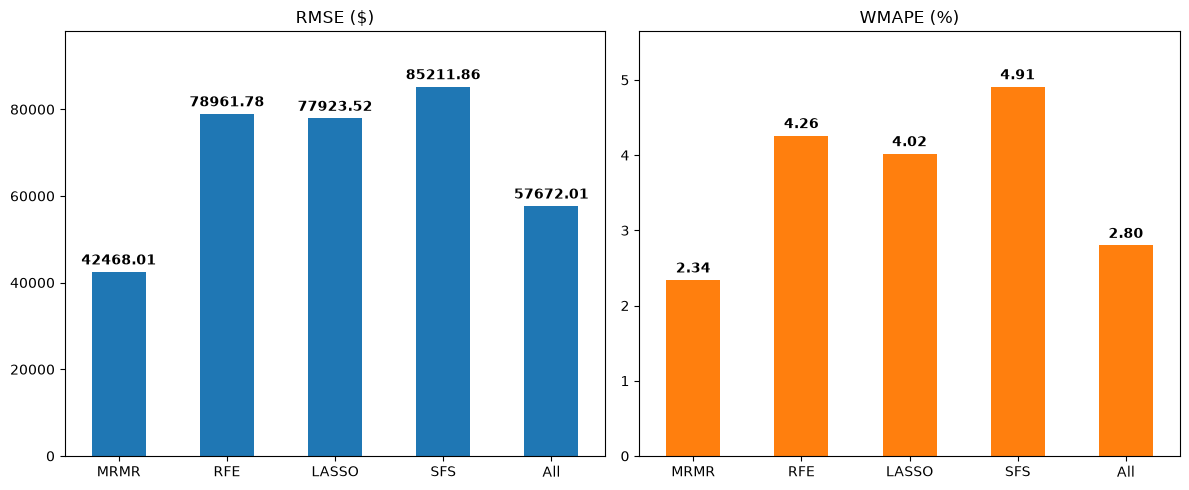

,RMSE ($),WMAPE (%)
MRMR,42468.01,2.34
RFE,78961.78,4.26
LASSO,77923.52,4.02
SFS,85211.86,4.91
All,57672.01,2.80


In [20]:
import matplotlib.pyplot as plt

def plot_results(df):
    # 1. Automatically plot all columns as subplots side-by-side
    ax = df.plot(kind='bar', subplots=True, layout=(1, len(df.columns)), figsize=(6 * len(df.columns), 5), rot=0, legend=False)
    
    # 2. Automatically push values on top of each bar and add top margin
    for i in range(len(df.columns)):
        ax[0, i].bar_label(ax[0, i].containers[0], fmt='%.2f', padding=3, fontweight='bold')
        ax[0, i].margins(y=0.15) # Automatically adds space at the top for labels
        
    plt.tight_layout()
    plt.show()

report_df = pd.DataFrame(results).T.round(2)
plot_results(report_df)
report_df